In [2]:
!pip install scikit-learn torch matplotlib numpy pandas

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 43.6 MB/s eta 0:00:00MB/s eta 0:00:01
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)


In [1]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import umap

In [2]:
# Load MiniLM
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

embed_model = AutoModel.from_pretrained(EMBED_MODEL_NAME)
embed_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_NAME)

In [3]:
#Define embedding function
def get_embedding(text):
    inputs = embed_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = embed_model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

In [4]:
# Load dataset
df = pd.read_csv("../datasets/train.csv")  #load dataset
print(f"Loaded {len(df)} rows")
print(df.columns)
print(df['target'].value_counts())  # 1 = disaster, 0 = not
df.head()

Loaded 7613 rows
Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')
target
0    4342
1    3271
Name: count, dtype: int64


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [5]:
#Sample of disaster + non-disaster tweets
sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(50, random_state=42)).reset_index(drop=True)

# Compute embeddings
sample_df["embedding"] = sample_df["text"].apply(get_embedding)

#Stack into matrix
X = np.vstack(sample_df["embedding"].values)
y = sample_df["target"].values

/var/folders/1l/d95jkyy90vs5p4tnw22bzkth0000gn/T/ipykernel_15071/2421717982.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(50, random_state=42)).reset_index(drop=True)


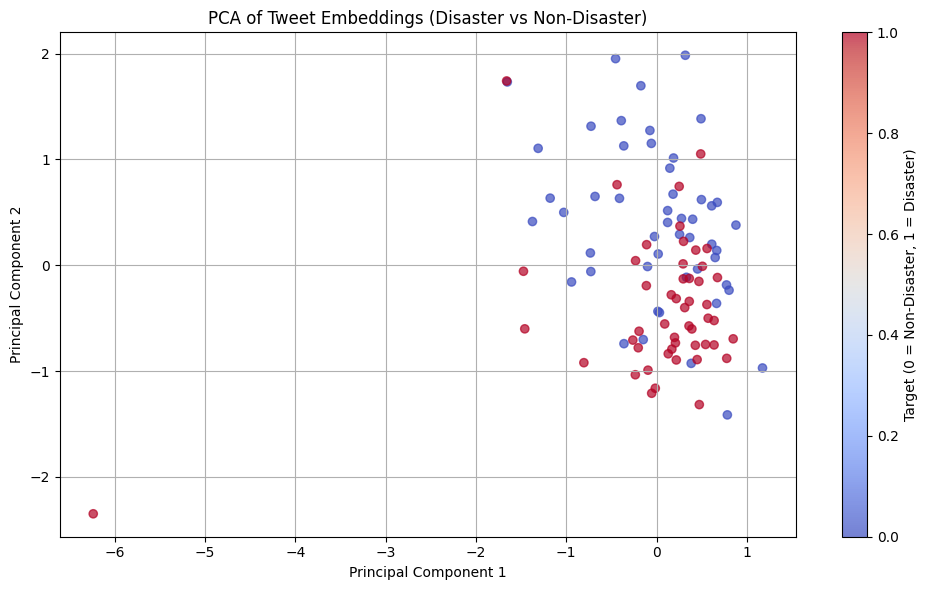

In [6]:
#Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("PCA of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


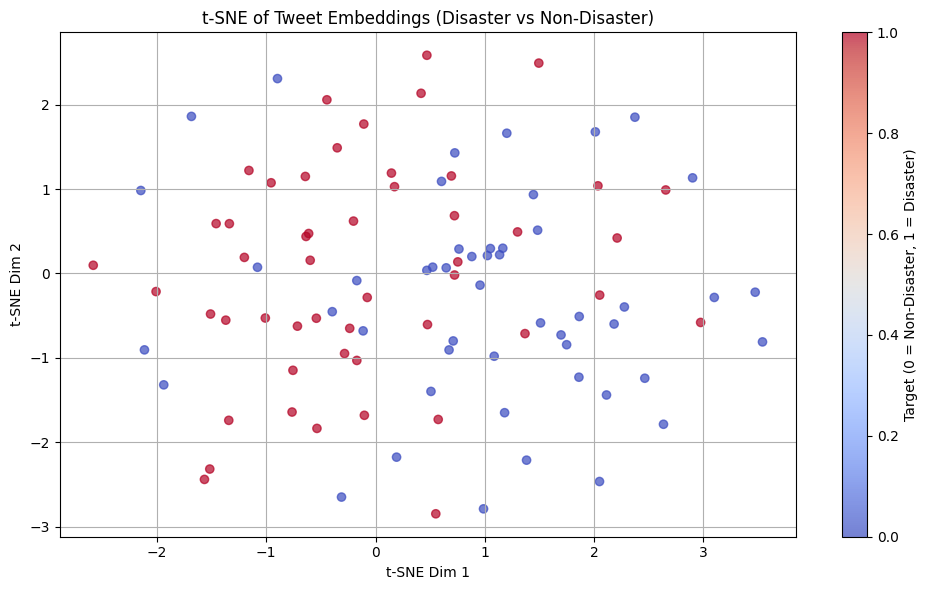

In [7]:
# Perform t-SNE computes
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("t-SNE of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
#Sample of disaster + non-disaster tweets
sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(75, random_state=42)).reset_index(drop=True)

# Compute embeddings
sample_df["embedding"] = sample_df["text"].apply(get_embedding)

#Stack into matrix
X = np.vstack(sample_df["embedding"].values)
y = sample_df["target"].values

/var/folders/1l/d95jkyy90vs5p4tnw22bzkth0000gn/T/ipykernel_15054/898081829.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(75, random_state=42)).reset_index(drop=True)


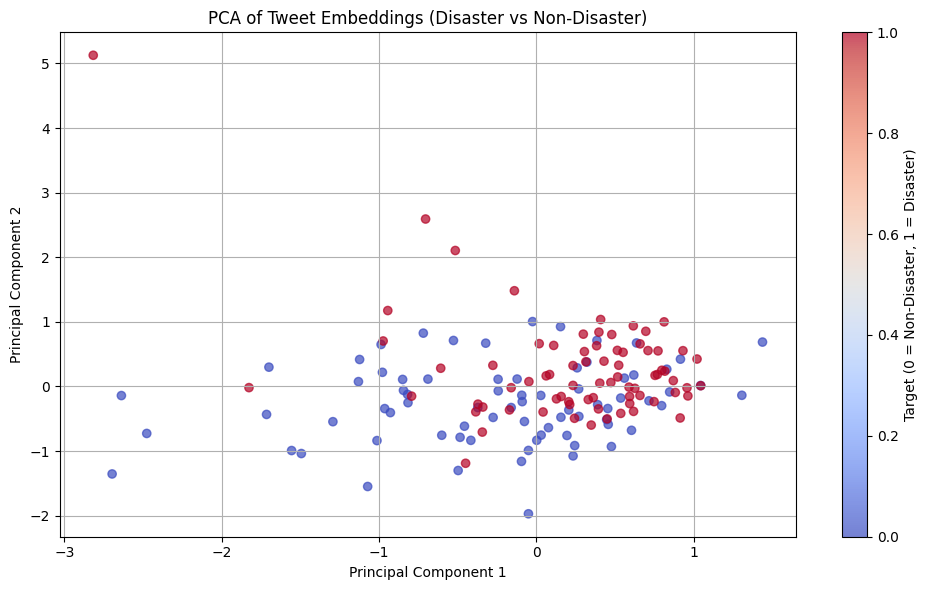

In [6]:
#Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("PCA of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


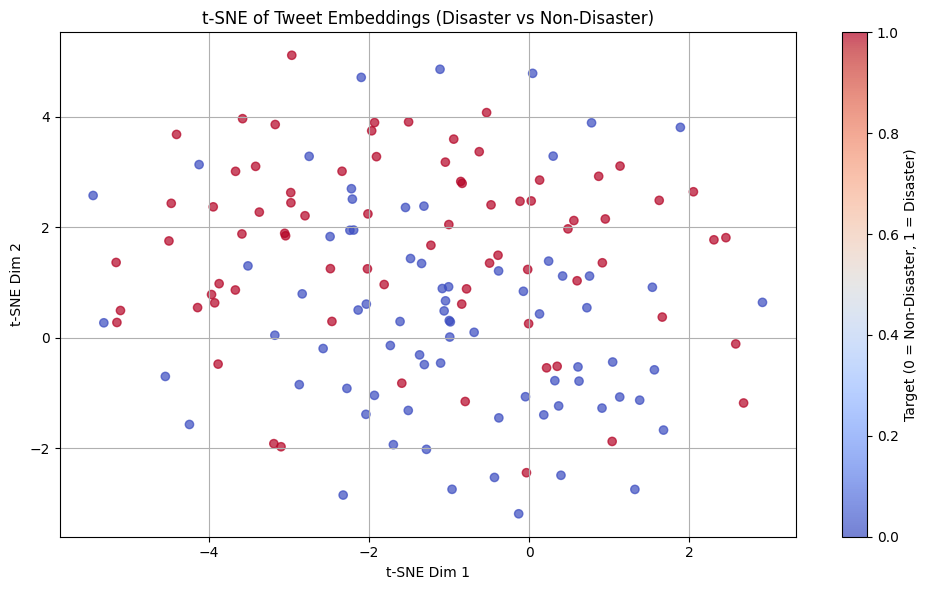

In [7]:
# Perform t-SNE computes
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("t-SNE of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
#Sample of disaster + non-disaster tweets
sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)

# Compute embeddings
sample_df["embedding"] = sample_df["text"].apply(get_embedding)

#Stack into matrix
X = np.vstack(sample_df["embedding"].values)
y = sample_df["target"].values

/var/folders/1l/d95jkyy90vs5p4tnw22bzkth0000gn/T/ipykernel_15081/2798327411.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(100, random_state=42)).reset_index(drop=True)


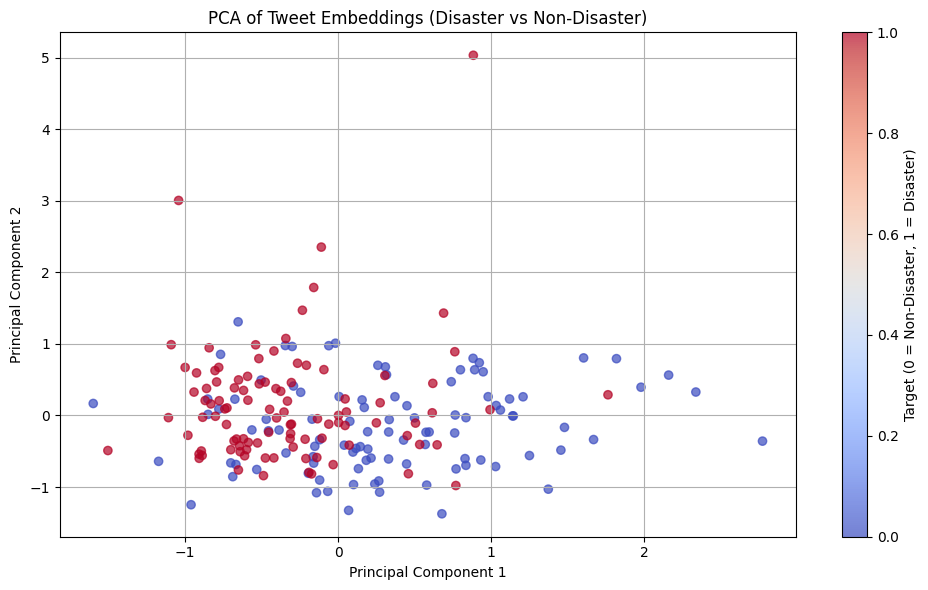

In [6]:
#Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("PCA of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Perform t-SNE computes
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("t-SNE of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
#Sample of disaster + non-disaster tweets
sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(50, random_state=42)).reset_index(drop=True)

# Compute embeddings
sample_df["embedding"] = sample_df["text"].apply(get_embedding)

#Stack into matrix
X = np.vstack(sample_df["embedding"].values)
y = sample_df["target"].values

/var/folders/1l/d95jkyy90vs5p4tnw22bzkth0000gn/T/ipykernel_15117/2421717982.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(50, random_state=42)).reset_index(drop=True)


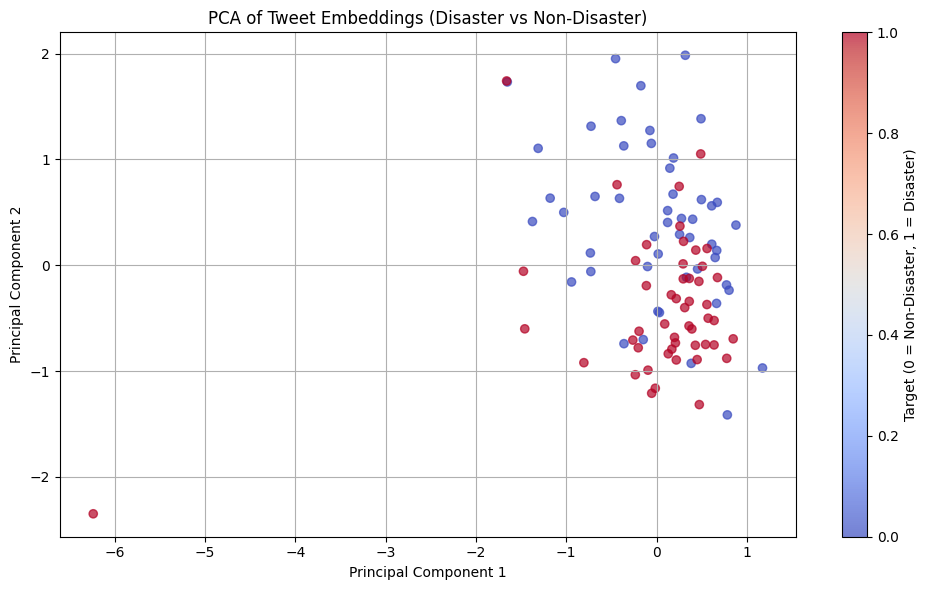

In [6]:
#Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("PCA of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


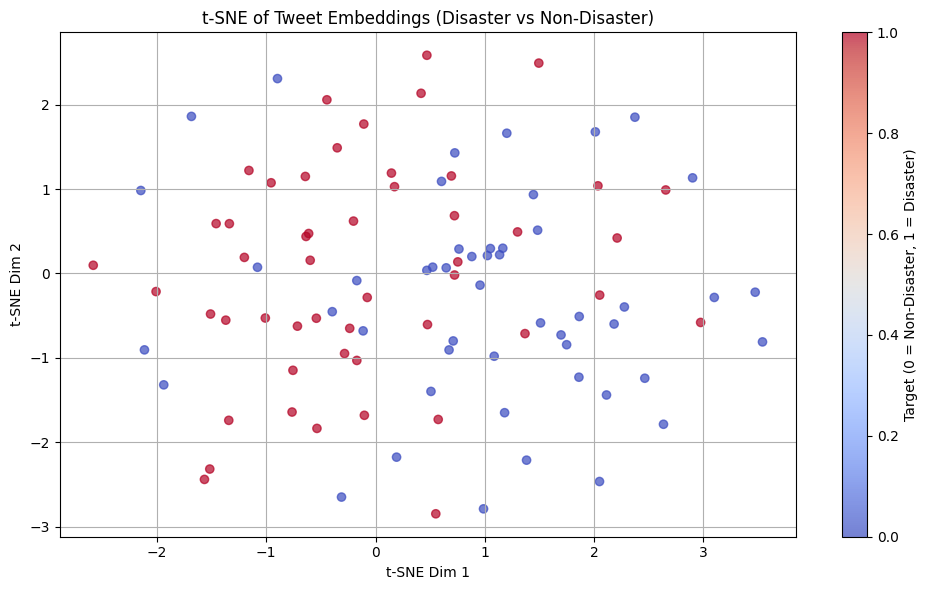

In [7]:
# Perform t-SNE computes
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("t-SNE of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

/Volumes/T7/dev/nlp-comp-env/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/T7/dev/nlp-comp-env/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


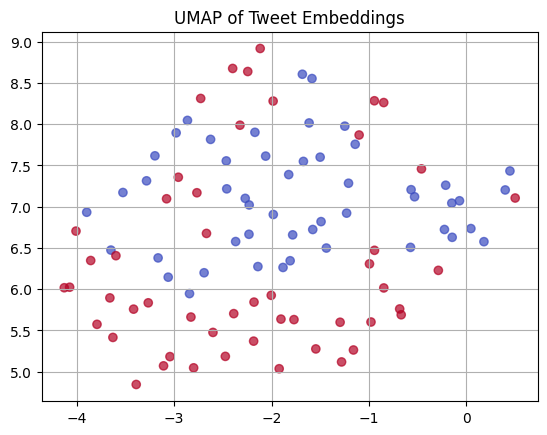

In [8]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("UMAP of Tweet Embeddings")
plt.grid(True)
plt.show()

In [9]:
#Sample of disaster + non-disaster tweets
sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(75, random_state=42)).reset_index(drop=True)

# Compute embeddings
sample_df["embedding"] = sample_df["text"].apply(get_embedding)

#Stack into matrix
X = np.vstack(sample_df["embedding"].values)
y = sample_df["target"].values

/var/folders/1l/d95jkyy90vs5p4tnw22bzkth0000gn/T/ipykernel_15117/898081829.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = df.groupby("target", group_keys=False).apply(lambda x: x.sample(75, random_state=42)).reset_index(drop=True)


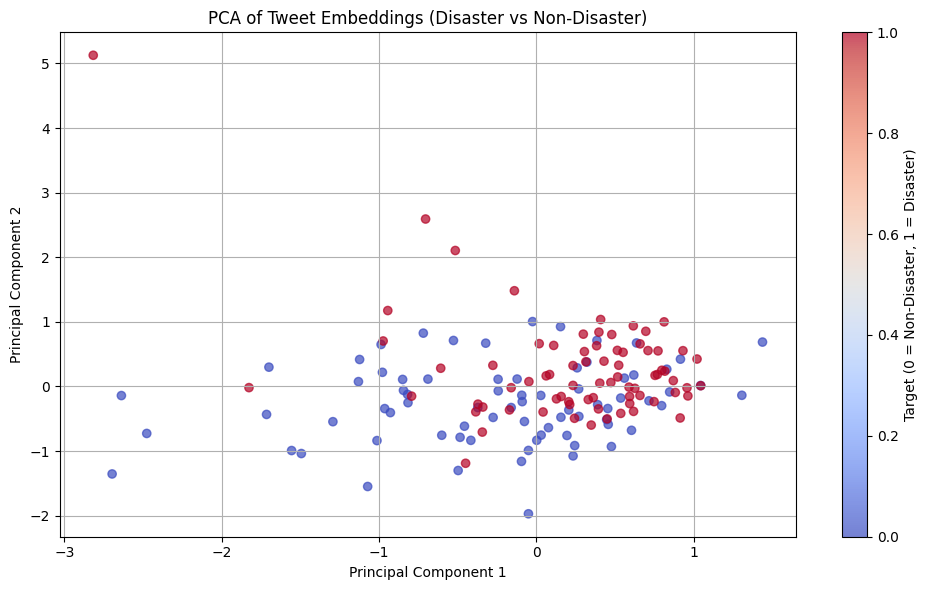

In [10]:
#Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("PCA of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

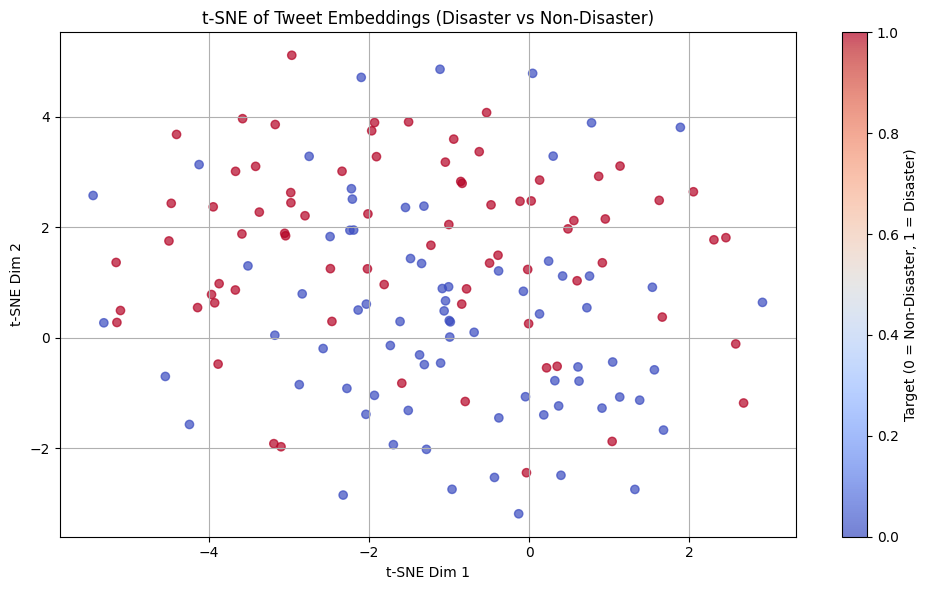

In [11]:
# Perform t-SNE computes
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("t-SNE of Tweet Embeddings (Disaster vs Non-Disaster)")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.colorbar(label="Target (0 = Non-Disaster, 1 = Disaster)")
plt.grid(True)
plt.tight_layout()
plt.show()

/Volumes/T7/dev/nlp-comp-env/env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Volumes/T7/dev/nlp-comp-env/env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


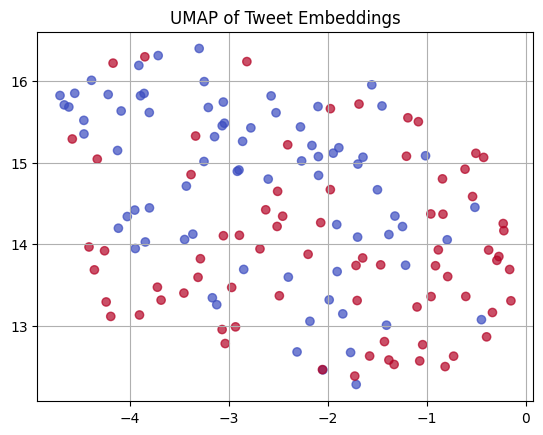

In [12]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("UMAP of Tweet Embeddings")
plt.grid(True)
plt.show()